## Chinook Sales Analysis

This project explores the Chinook database, which contains information about customers, invoices, tracks, albums, artists, and genres.

The goal is to understand the store's sales performance and customer behavior by answering questions like:

* How has revenue changed over time?
* Which months and years generate the most revenue?
* Which customers contribute the most revenue?
* Do some artists generate more revenue per track?
* Which countries have the highest revenue per customer?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.ticker import MaxNLocator

import mysql.connector
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from dotenv import load_dotenv

os.makedirs("visuals", exist_ok=True)

load_dotenv()

password = os.getenv("MYSQL_PASSWORD")

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password=password,
    database="chinook"
)

connection_url = URL.create(
    "mysql+mysqlconnector",
    username="root",
    password=password,
    host="localhost",
    port=3306,
    database="chinook"
)

engine = create_engine(connection_url)

In [2]:
def run_query(query):
    return pd.read_sql(query, engine)

## 1. Revenue Trends Over Time

Analyze how revenue changes month by month and identify periods of higher or lower sales.

In [3]:
query = """
select date_format(InvoiceDate, '%Y-%m') as invoice_month,
round(sum(Total), 2) AS revenue
from Invoice
group by date_format(InvoiceDate, '%Y-%m')
order by invoice_month;
"""

revenue_by_month = run_query(query)

In [4]:
revenue_by_month.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   invoice_month  60 non-null     str    
 1   revenue        60 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.1 KB


In [5]:
revenue_by_month.head()

,invoice_month,revenue
0,2021-01,35.64
1,2021-02,37.62
2,2021-03,37.62
3,2021-04,37.62
4,2021-05,37.62


In [6]:
revenue_by_month["revenue_growth"] = (
    revenue_by_month["revenue"].pct_change() * 100
)
revenue_by_month.head(5)

,invoice_month,revenue,revenue_growth
0,2021-01,35.64,NaN
1,2021-02,37.62,5.555556
2,2021-03,37.62,0.000000
3,2021-04,37.62,0.000000
4,2021-05,37.62,0.000000


In [7]:
revenue_by_month.nlargest(5, "revenue_growth")

,invoice_month,revenue,revenue_growth
35,2023-12,37.62,58.333333
12,2022-01,52.62,39.872408
27,2023-04,51.62,37.214248
50,2025-03,37.62,35.714286
58,2025-11,49.62,31.897927


In [8]:
revenue_by_month.nsmallest(5,"revenue_growth")

,invoice_month,revenue,revenue_growth
34,2023-11,23.76,-36.842105
49,2025-02,27.72,-26.315789
30,2023-07,37.62,-25.681549
59,2025-12,38.62,-22.168480
28,2023-05,42.62,-17.435103


In [9]:
revenue_by_month["invoice_month"] = pd.to_datetime(
    revenue_by_month["invoice_month"]
)

revenue_by_month.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_month   60 non-null     datetime64[us]
 1   revenue         60 non-null     float64       
 2   revenue_growth  59 non-null     float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 1.5 KB


In [10]:
revenue_2023 = revenue_by_month[
    revenue_by_month["invoice_month"].dt.year == 2023
]

revenue_2023

,invoice_month,revenue,revenue_growth
24,2023-01-01,37.62,0.000000
25,2023-02-01,37.62,0.000000
26,2023-03-01,37.62,0.000000
27,2023-04-01,51.62,37.214248
28,2023-05-01,42.62,-17.435103
29,2023-06-01,50.62,18.770530
30,2023-07-01,37.62,-25.681549
31,2023-08-01,37.62,0.000000
32,2023-09-01,37.62,0.000000
33,2023-10-01,37.62,0.000000


### Key Finding

> April had the highest revenue in 2023 at **$51.62**. December had the biggest jump from the previous month, with revenue growing by **58.33%**. This was mainly because November had unusually low revenue.


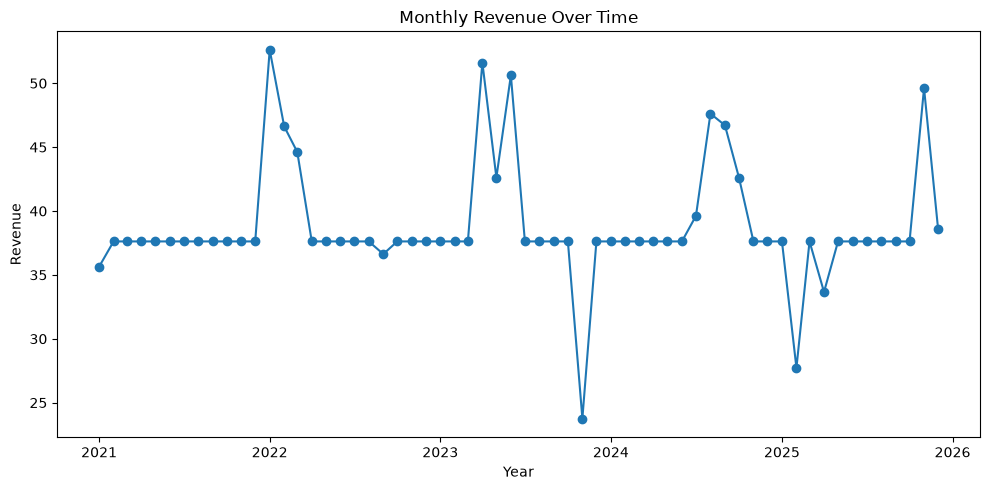

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(
    revenue_by_month["invoice_month"],
    revenue_by_month["revenue"],
    marker="o")
plt.title("Monthly Revenue Over Time")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("monthly_revenue_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
query = """
select year(InvoiceDate) as invoice_year,
round(sum(Total), 2) as revenue
from invoice
group by year(InvoiceDate)
order by invoice_year;
"""

revenue_over_year = run_query(query)

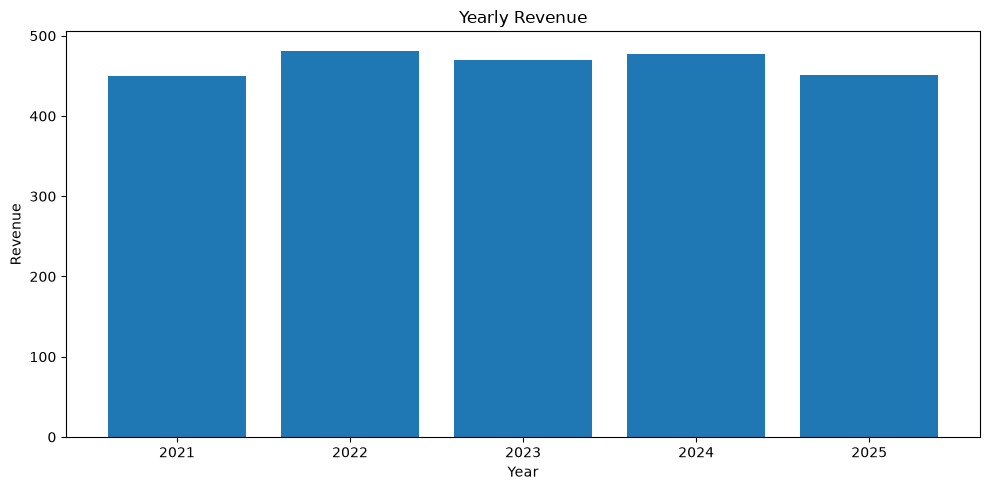

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(
    revenue_over_year["invoice_year"],
    revenue_over_year["revenue"]
)
plt.title("Yearly Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("yearly_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
revenue_over_year["revenue_growth"] = (
    revenue_over_year["revenue"].pct_change() * 100
)
revenue_over_year.head(20)

,invoice_year,revenue,revenue_growth
0,2021,449.46,NaN
1,2022,481.45,7.117430
2,2023,469.58,-2.465469
3,2024,477.53,1.693002
4,2025,450.58,-5.643624


## Key Finding

> Revenue peaked in 2022 at **$481.45**, growing by **7.12%** from 2021. After that, revenue declined by **2.47%** in 2023, recovered slightly by **1.69%** in 2024, and then dropped by **5.64%** in 2025. Overall, revenue remained fairly stable, but the trend has been downward since 2022.


## 2. What is the average invoice value, and how does it vary?

In [15]:
query = """
select round(avg(Total), 2) as average_invoice_value
from invoice;
"""

average_invoice_value = run_query(query)
average_invoice_value

,average_invoice_value
0,5.65


In [16]:
query = """
select Total
from invoice;
"""

invoice_values = run_query(query)

In [17]:
invoice_values["Total"].describe()

count    412.000000
mean       5.651942
std        4.745320
min        0.990000
25%        1.980000
50%        3.960000
75%        8.910000
max       25.860000
Name: Total, dtype: float64

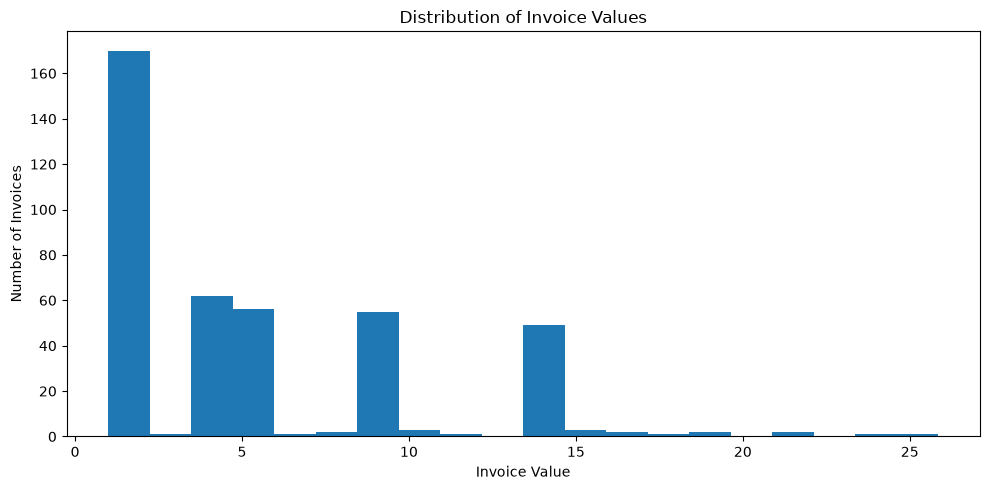

In [18]:
plt.figure(figsize=(10, 5))

plt.hist(invoice_values["Total"], bins=20)
plt.title("Distribution of Invoice Values")
plt.xlabel("Invoice Value")
plt.ylabel("Number of Invoices")
plt.tight_layout()
plt.savefig("invoice_value_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Key Finding

> The average invoice value was **5.65**, while the median invoice value was **3.96**. Most invoices were relatively low in value, with **75% of invoices totaling 8.91 or less**. However, some higher-value invoices reached **25.86**, which helped pull the average above the median.


## 3. What percentage of revenue comes from the top customers?

In [19]:
query = """
select concat(c.FirstName, ' ', c.LastName) as full_name, 
round(sum(i.Total),2) as total_spent, count(i.InvoiceId) as number_of_purchases
from Customer c
inner join Invoice i
on c.CustomerId = i.CustomerId
group by c.CustomerId, c.FirstName, c.LastName
order by total_spent desc;
"""

revenue_from_customers = run_query(query)
revenue_from_customers

,full_name,total_spent,number_of_purchases
0,Helena Holý,49.62,7
1,Richard Cunningham,47.62,7
2,Luis Rojas,46.62,7
3,Ladislav Kovács,45.62,7
4,Hugh O'Reilly,45.62,7
5,Julia Barnett,43.62,7
6,Fynn Zimmermann,43.62,7
7,Frank Ralston,43.62,7
8,Astrid Gruber,42.62,7
9,Victor Stevens,42.62,7


In [20]:
revenue_from_customers["cumulative_revenue"] = (
    revenue_from_customers["total_spent"].cumsum()
)
revenue_from_customers

,full_name,total_spent,number_of_purchases,cumulative_revenue
0,Helena Holý,49.62,7,49.62
1,Richard Cunningham,47.62,7,97.24
2,Luis Rojas,46.62,7,143.86
3,Ladislav Kovács,45.62,7,189.48
4,Hugh O'Reilly,45.62,7,235.10
5,Julia Barnett,43.62,7,278.72
6,Fynn Zimmermann,43.62,7,322.34
7,Frank Ralston,43.62,7,365.96
8,Astrid Gruber,42.62,7,408.58
9,Victor Stevens,42.62,7,451.20


In [21]:
top_10_percent_count = round(len(revenue_from_customers) * 0.10)

top_customers = revenue_from_customers.head(top_10_percent_count)

top_customers

,full_name,total_spent,number_of_purchases,cumulative_revenue
0,Helena Holý,49.62,7,49.62
1,Richard Cunningham,47.62,7,97.24
2,Luis Rojas,46.62,7,143.86
3,Ladislav Kovács,45.62,7,189.48
4,Hugh O'Reilly,45.62,7,235.10
5,Julia Barnett,43.62,7,278.72


In [22]:
top_revenue = top_customers["total_spent"].sum()
revenue_share = ( top_revenue / revenue_from_customers["total_spent"].sum()) * 100
revenue_share

np.float64(11.96942368805291)

## Key Finding:

> The top 10% of customers generated approximately **11.97% of total revenue**, showing that revenue is relatively evenly distributed across customers.

## 4.Which artists generate high revenue with relatively few tracks?

In [23]:
query = """
select ar.Name as artist,
count(distinct t.TrackId) as number_of_tracks,
sum(il.Quantity) as units_sold,
round(sum(il.Quantity * il.UnitPrice),2) as revenue
from Artist ar
join Album al
on ar.ArtistId = al.ArtistId
join Track t
on al.AlbumId = t.AlbumId
join InvoiceLine il
on t.TrackId = il.TrackId
group by ar.ArtistId, ar.Name
order by revenue desc;
"""

artist_revenue = run_query(query)
artist_revenue

,artist,number_of_tracks,units_sold,revenue
0,Iron Maiden,123,140.0,138.60
1,U2,91,107.0,105.93
2,Metallica,79,91.0,90.09
3,Led Zeppelin,77,87.0,86.13
4,Lost,40,41.0,81.59
...,...,...,...,...
160,Kent Nagano and Orchestre de l'Opéra de Lyon,1,1.0,0.99
161,Julian Bream,1,1.0,0.99
162,Martin Roscoe,1,1.0,0.99
163,Göteborgs Symfoniker & Neeme Järvi,1,1.0,0.99


In [24]:
artist_revenue["revenue_per_track"] = ( artist_revenue["revenue"] / artist_revenue["number_of_tracks"])
artist_revenue

,artist,number_of_tracks,units_sold,revenue,revenue_per_track
0,Iron Maiden,123,140.0,138.60,1.126829
1,U2,91,107.0,105.93,1.164066
2,Metallica,79,91.0,90.09,1.140380
3,Led Zeppelin,77,87.0,86.13,1.118571
4,Lost,40,41.0,81.59,2.039750
...,...,...,...,...,...
160,Kent Nagano and Orchestre de l'Opéra de Lyon,1,1.0,0.99,0.990000
161,Julian Bream,1,1.0,0.99,0.990000
162,Martin Roscoe,1,1.0,0.99,0.990000
163,Göteborgs Symfoniker & Neeme Järvi,1,1.0,0.99,0.990000


In [25]:
artist_revenue_filtered = artist_revenue[artist_revenue["number_of_tracks"] >= 10]

top_artists = artist_revenue_filtered.sort_values( "revenue_per_track",   ascending=False).head(10)

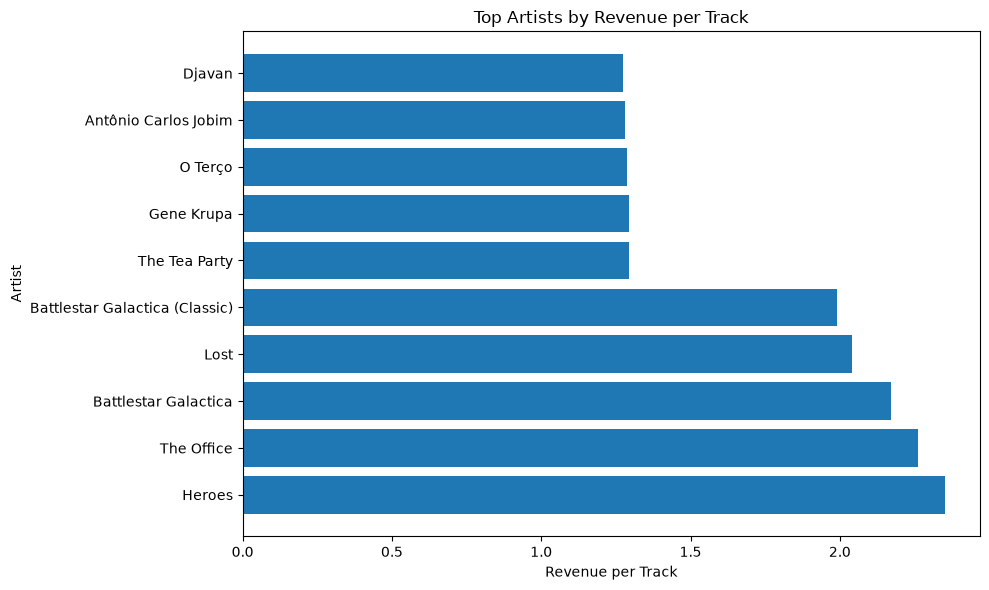

In [26]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_artists["artist"],
    top_artists["revenue_per_track"]
)

plt.title("Top Artists by Revenue per Track")
plt.xlabel("Revenue per Track")
plt.ylabel("Artist")

plt.tight_layout()
plt.savefig("top_artists_revenue_per_track.png", dpi=300, bbox_inches="tight")
plt.show()

## Key Finding

> Heroes generated the highest revenue per track at **2.35 dollars**, despite having only 11 tracks. In comparison, Iron Maiden generated the highest total revenue at **138.60 dollars**, but earned about **1.13 dollars per track**. This shows that the artist with the highest overall revenue isn't necessarily the most efficient in revenue per track.


## 5. Revenue per Customer by Country

In [27]:
query = """
select c.Country as country,
count(distinct c.CustomerId) as number_of_customers,
round(sum(i.Total),2) as total_revenue
from Customer c
join Invoice i
on c.CustomerId = i.CustomerId
group by c.Country
order by total_revenue desc;
"""

country_revenue = run_query(query)
country_revenue

,country,number_of_customers,total_revenue
0,USA,13,523.06
1,Canada,8,303.96
2,France,5,195.10
3,Brazil,5,190.10
4,Germany,4,156.48
5,United Kingdom,3,112.86
6,Czech Republic,2,90.24
7,Portugal,2,77.24
8,India,2,75.26
9,Chile,1,46.62


In [28]:
country_revenue["revenue_per_customer"] = (country_revenue["total_revenue"] / country_revenue["number_of_customers"])

In [29]:
country_revenue_filtered = country_revenue[ country_revenue["number_of_customers"] >= 3]
country_revenue_filtered.sort_values( "revenue_per_customer", ascending=False)

,country,number_of_customers,total_revenue,revenue_per_customer
0,USA,13,523.06,40.235385
4,Germany,4,156.48,39.120000
2,France,5,195.10,39.020000
3,Brazil,5,190.10,38.020000
1,Canada,8,303.96,37.995000
5,United Kingdom,3,112.86,37.620000


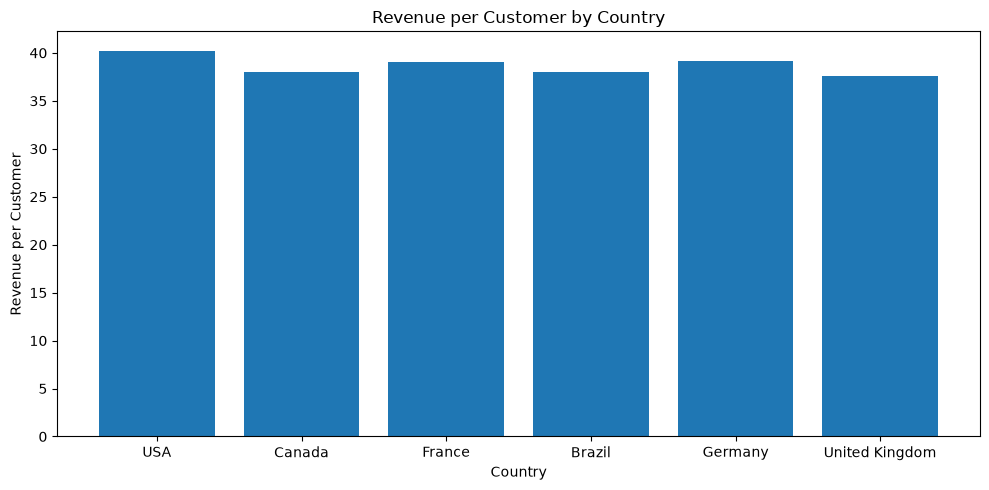

In [30]:
plt.figure(figsize=(10, 5))
plt.bar(
    country_revenue_filtered["country"],
    country_revenue_filtered["revenue_per_customer"])
plt.title("Revenue per Customer by Country")
plt.xlabel("Country")
plt.ylabel("Revenue per Customer")
plt.tight_layout()
plt.savefig("revenue_per_customer_by_country.png", dpi=300, bbox_inches="tight")
plt.show()

## Key Finding

> Among countries with at least 3 customers, the USA had the highest average revenue per customer at **40.24 dollars**, followed by Germany at **39.12 dollars** and France at **39.02 dollars**. The difference between the highest and lowest averages was relatively small, suggesting that customer spending was fairly consistent across these countries.


## Conclusion

Overall, Chinook's revenue was fairly stable throughout the years, with 2022 being the strongest year before revenue dropped slightly afterward. Monthly revenue was also quite consistent, with only small differences between the highest and lowest months. The analysis also showed that a small group of customers contributed a significant share of the revenue, while customer spending was fairly similar across the countries with enough customers for comparison.

This project helped me practice using SQL to answer business questions and Python to take the analysis further through calculations and visualizations.
